# Entropy of child language 

In this exploration of child language, we will use the notion of entropy to compare child-directed speech with speech produced by a child.  The data we will rely on are from the Adam section of the Brown corpus in the [CHILDES dataset](https://childes.talkbank.org/) - and will be in XML format.

In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
from collections import Counter
import math
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

### Read in data

In [2]:
fname = 'Brown/Adam/020304.xml' # first adam file
#fname = 'Brown/Adam/050212.xml' # last adam file

# access the data from a file.
with open(fname, "r") as f:
    data = f.read()
print(data)

<?xml version="1.0" encoding="UTF-8"?>

<CHAT xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"
      xmlns="http://www.talkbank.org/ns/talkbank"
      xsi:schemaLocation="http://www.talkbank.org/ns/talkbank https://talkbank.org/software/talkbank.xsd"
            DesignType="long"
            ActivityType="toyplay"
            GroupType="TD"
      PID="11312/c-00015632-1"
      Version="2.16.0"
      Lang="eng"
      Corpus="Brown"
      Date="1962-10-08"
      >
  <Participants>
    <participant
      id="CHI"
    name="Adam"
      role="Target_Child"
      language="eng"
      age="P2Y03M04D"
      sex="male"
      group="typical"
      SES="MC"

    />
    <participant
      id="MOT"
      role="Mother"
      language="eng"
      sex="female"

    />
    <participant
      id="URS"
    name="Ursula_Bellugi"
      role="Investigator"
      language="eng"

    />
    <participant
      id="RIC"
    name="Richard_Cromer"
      role="Investigator"
      language="eng"

    />
    <p

In [3]:
# get namespaces in usable form.
# nss stands for "namespaces"
nss = dict([node for _, node in ET.iterparse(StringIO(data), events=['start-ns'])])
print(nss)
print(nss[''])
th = '{' + nss[''] + '}'  # tag header for default namespace
print(th)

{'xsi': 'http://www.w3.org/2001/XMLSchema-instance', '': 'http://www.talkbank.org/ns/talkbank'}
http://www.talkbank.org/ns/talkbank
{http://www.talkbank.org/ns/talkbank}


In [4]:
# organize that as an ElementTree.
root = ET.fromstring(data)
print(root)

<Element '{http://www.talkbank.org/ns/talkbank}CHAT' at 0x7d9d19b273d0>


In [5]:
# first examine the root of the tree you just read in
print(root.tag)
print(root.attrib)

{http://www.talkbank.org/ns/talkbank}CHAT
{'{http://www.w3.org/2001/XMLSchema-instance}schemaLocation': 'http://www.talkbank.org/ns/talkbank https://talkbank.org/software/talkbank.xsd', 'DesignType': 'long', 'ActivityType': 'toyplay', 'GroupType': 'TD', 'PID': '11312/c-00015632-1', 'Version': '2.16.0', 'Lang': 'eng', 'Corpus': 'Brown', 'Date': '1962-10-08'}


In [6]:
# pull out date of data collection
print("Date of data collection:", root.attrib['Date'])

Date of data collection: 1962-10-08


In [7]:
# now look at children of root node.
for child in root:
    print(child.tag,child.attrib)

{http://www.talkbank.org/ns/talkbank}Participants {}
{http://www.talkbank.org/ns/talkbank}comment {'type': 'Date'}
{http://www.talkbank.org/ns/talkbank}comment {'type': 'Generic'}
{http://www.talkbank.org/ns/talkbank}comment {'type': 'Time Duration'}
{http://www.talkbank.org/ns/talkbank}comment {'type': 'Types'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'CHI', 'uID': 'u0'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'CHI', 'uID': 'u1'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'MOT', 'uID': 'u2'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'CHI', 'uID': 'u3'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'CHI', 'uID': 'u4'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'CHI', 'uID': 'u5'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'CHI', 'uID': 'u6'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'MOT', 'uID': 'u7'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'CHI', 'uID': 'u8'}
{http://www.talkbank.org/ns/talkbank}u {'who': 'MOT', 'uID': 'u9'}
{http://www.talk

In [8]:
# let's take a closer look at the participants.
# note that there is a header for many of the tags - need to include it.
for p in root.iter(th+'participant'):  # tag for participant
    print(p.attrib)

{'id': 'CHI', 'name': 'Adam', 'role': 'Target_Child', 'language': 'eng', 'age': 'P2Y03M04D', 'sex': 'male', 'group': 'typical', 'SES': 'MC'}
{'id': 'MOT', 'role': 'Mother', 'language': 'eng', 'sex': 'female'}
{'id': 'URS', 'name': 'Ursula_Bellugi', 'role': 'Investigator', 'language': 'eng'}
{'id': 'RIC', 'name': 'Richard_Cromer', 'role': 'Investigator', 'language': 'eng'}
{'id': 'COL', 'name': 'Colin_Fraser', 'role': 'Investigator', 'language': 'eng'}


In [9]:
# now recursively traverse the entire tree, pulling out utterances only, and printing them.
for utt in root.iter(th+'u'):  # 'u' = tag for utterance
    who = utt.attrib['who']
    print(who, ": ", end="")
    ll = []
    for word in utt.findall(th+'w'):
        if word.text != None:  # ignore null words, of which there are some
            ll.append(word.text)
    print(ll)

CHI : ['play', 'checkers']
CHI : ['big', 'drum']
MOT : ['big', 'drum']
CHI : ['big', 'drum']
CHI : ['big', 'drum']
CHI : ['big', 'drum']
CHI : ['horse']
MOT : ['horse']
CHI : ['who']
MOT : ['who', 'is', 'that']
MOT : ['those', 'are', 'checkers']
CHI : ['two', 'check']
MOT : ['two', 'checkers', 'yes']
CHI : ['rig', 'horn']
CHI : ['p', 'check']
MOT : ['play', 'checkers']
CHI : ['yep']
CHI : ['big', 'horn']
MOT : ['big', 'horn']
CHI : ['alright', 'look', 'tv']
CHI : ['part']
CHI : ['part']
CHI : ['part']
CHI : ['part']
CHI : ['part']
CHI : ['ge', 'over', 'Mommy']
MOT : ['get', 'over', 'Mommy']
CHI : ['nickel']
CHI : ['nickel']
CHI : ['nickel']
CHI : ['nickel']
CHI : ['shadow']
CHI : ['shadow']
CHI : ['shadow']
CHI : ['shadow']
MOT : ['shadow']
CHI : ['yeah', 'shadow', 'yeah']
CHI : ['shadow', 'funny']
CHI : ['put', 'dirt', 'up']
CHI : ['put', 'dirt', 'up']
CHI : ['put', 'dirt', 'up']
CHI : ['sit', 'dere']
CHI : ['sit', 'dere']
CHI : ['sit', 'dere']
CHI : ['read', 'Shadow']
CHI : ['read', 

Now store that data in a Pandas dataframe.  How?  An [efficient way](https://stackoverflow.com/a/17496530) to do that is:

- First create a list of dictionaries, in which each dictionary corresponds to an input data row, and will become a Pandas dataframe row.
- Then create a Pandas dataframe from this list of dictionaries.

What does that look like in more detail?

- Our dataframe will have 2 columns: Who (who is the speaker) and Utt (what was their utterance).
- This means each dict will have 2 keys: 'Who', with associated value being either 'MOT' (mother) or 'CHI' (child), and Utt, with associated value being the utterance produced by that speaker, in the form of a list of words.

---
**4 points for the following cell**:
 - 2 points for creating a dataframe that contains the right information
 - 2 points for having the right information in the right place in the dataframe

In [10]:
rows_list = []  # initialize list of dicts to hold rows of df-to-be.

# YOUR CODE GOES HERE.  
# in building up the list of words for each utterance, please ignore null words, of which there are some.
for utt in root.iter(th+'u'):  # 'u' = tag for utterance
    who = utt.attrib['who']
    # print(who, ": ", end="")
    newdict = {'Who':who}
    rows_list.append
    ll = []
    for word in utt.findall(th+'w'):
        if word.text != None:  # ignore null words, of which there are some
            ll.append(word.text)
    newdict['Utt'] = ll
    rows_list.append(newdict)

# for item in rows_list:
#     print(item)

# at this point we have filled up rows_list with the content we want to create a df out of.
# so go ahead and create the df:
df = pd.DataFrame(rows_list)
df

,Who,Utt
0,CHI,"[play, checkers]"
1,CHI,"[big, drum]"
2,MOT,"[big, drum]"
3,CHI,"[big, drum]"
4,CHI,"[big, drum]"
...,...,...
1732,CHI,"[who, dat]"
1733,MOT,"[what, is, that]"
1734,CHI,[green]
1735,CHI,"[find, green]"


### We're back in Pandas-land!

- With our data in a format we're familiar with, we can now start analyzing.
- Start by sampling a few utterances from mother, and from child.
- Then calculate MLU, or mean length of utterance, for mother (MOT) and child (CHI) separately.

In [11]:
# sample a few mother utterances, just to get a feel for what's there.
mdf = df[df.Who=='MOT']  # mother df
mdf.sample(n=25)

,Who,Utt
9,MOT,"[who, is, that]"
162,MOT,"[Adam, Smith]"
1596,MOT,"[build, a, castle, out_of]"
1577,MOT,"[whenever, there's, a, hill, to, climb]"
330,MOT,"[what, is, that]"
544,MOT,"[you, leave, his, pencil, in, there, Adam]"
238,MOT,[no]
452,MOT,"[what, is, that]"
1182,MOT,"[who, is, this]"
662,MOT,"[how, can, you, work]"


In [12]:
# sample a few child utterances.
cdf = df[df.Who=='CHI']  # child df
cdf.sample(n=25)

,Who,Utt
11,CHI,"[two, check]"
1562,CHI,"[who, dat]"
1511,CHI,"[wee_wee, way, home]"
818,CHI,[church]
1223,CHI,"[trailer, trailer]"
1579,CHI,[climb]
131,CHI,[there]
893,CHI,[okay]
1386,CHI,"[Judy, Bu]"
1006,CHI,"[put, water, in]"


In [13]:
# now get MLU for mother and child.
print("Mother's MLU:", mdf.Utt.apply(len).mean())
print("Child's MLU:", cdf.Utt.apply(len).mean())

Mother's MLU: 4.064732142857143
Child's MLU: 2.0078864353312302


In [14]:
# now also get min and max length of utterance for mother and child, to get a fuller picture.
print("Mother's min LU:", mdf.Utt.apply(len).min())
print("Mother's MLU:", mdf.Utt.apply(len).mean())
print("Mother's max LU:", mdf.Utt.apply(len).max())
print()

print("Child's min LU:", cdf.Utt.apply(len).min())
print("Child's MLU:", cdf.Utt.apply(len).mean())
print("Child's max LU:", cdf.Utt.apply(len).max())

Mother's min LU: 0
Mother's MLU: 4.064732142857143
Mother's max LU: 12

Child's min LU: 0
Child's MLU: 2.0078864353312302
Child's max LU: 14


OK, that kind of makes sense, but only partly.

- It makes a lot of sense that MLU would be greater for mother than child.
- But why is child's max LU greater than that of mother?

In [15]:
# let's poke around and find out - what are those long child-produced utterances?
maxlen = cdf.Utt.apply(len).max()
long_child_utts = cdf[cdf.Utt.apply(len)== maxlen]
long_child_utts

,Who,Utt
885,CHI,"[bulldozer, bulldozer, bulldozer, bulldozer, b..."


In [16]:
# aha.  take a closer look at the entire utterance.
utt = long_child_utts.Utt.values[0]
print(len(utt))
utt

14


['bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer',
 'bulldozer']

### Beyond MLU

This is actually a useful example: it illustrates why length of utterance is not always a good measure of  the complexity of language use.  

A different measure would be the **entropy** of a person's speech, which measures how unpredictable it is.  More complex speech should be less predictable, and therefore have higher entropy.

How do we measure entropy?  The equation is straightforward enough:

\begin{equation}
H(x) = \sum_{i=1}^m p(x_i) \log \frac{1}{p(x_i)}
\end{equation}

but to apply it here, we need to answer a central question.

What units are we counting and tracking the probabilities of?  What **should** we count and track?  Based on the utterance samples above, one thing that intuitively seems to distinguish mother's speech from child's speech (apart from grammaticality) is that the mother produces sentences of quite varying length - some very short and some quite long - and, when her sentences are long, they are long not only because of repetition of the "bulldozer+" variety - instead, they contain many different words.  This suggests that a reasonable unit to count might be the **number of distinct words in an utterance**.  We expect this quantity to be relatively uncertain (high entropy) for the mother, and more certain (lower entropy) for the child.

We will calculate this quantity for mother and for child, separately, and get histograms for each.  That is, for each number of distinct words per utterance (0, 1, 2, ...), we will count the number of utterances by a given speaker that had that number of distinct words in it.  We will then turn those counts into probability distributions by normalizing: divide each count by the total count for that speaker.

### Counting distinct words per utterance

- Start by extracting utterances for each speaker.  
- Then count the number of distinct words in each utterance.
- Then turn those counts into probabilities.

In [17]:
# get utterances, for MOT and CHI separately.
utts = dict()  # key = who; value = utterances for that speaker, as array of lists of words.
for who in ['MOT','CHI']:
    utts[who] = df[df.Who==who].Utt.values
utts

{'MOT': array([list(['big', 'drum']), list(['horse']),
        list(['who', 'is', 'that']), list(['those', 'are', 'checkers']),
        list(['two', 'checkers', 'yes']), list(['play', 'checkers']),
        list(['big', 'horn']), list(['get', 'over', 'Mommy']),
        list(['shadow']), list(['I', 'like', 'it']),
        list(['why', "don't", 'you', 'read', 'Shadow', 'yourself']),
        list(["that's", 'a', 'terribly', 'small', 'horse', 'for', 'you', 'to', 'ride']),
        list(['why', "don't", 'you', 'look', 'at', 'some', 'of', 'the', 'toys', 'in', 'the', 'basket']),
        list(['wanna']),
        list(['do', 'you', 'wanna', 'see', 'what', 'I', 'have']),
        list(['what', 'is', 'that']), list(['not', 'in', 'your', 'mouth']),
        list(['let', 'me', 'put', 'them', 'together']),
        list(['no', 'put', 'floor']),
        list(['no', "that's", 'his', 'pencil']),
        list(["that's", 'not', 'Daddy', "that's", 'Colin']),
        list(['I', 'think', 'perhaps', "he's", 'goin

---
**4 points for the following cell**:
 - 2 points for creating a data structure that contains the right information
 - 2 points for having the right information in the right place in the data structure

In [18]:
# get the number of distinct words in each utterance, by speaker.
distinct = dict()  # key = who; value = list of num distinct words per utt, as one long list.

# YOUR CODE GOES HERE.
# print(utts['MOT'])

for key in utts.keys():
    lst = []
    for sentence in utts[key]:
        words = set()
        for word in sentence:
            words.add(word)
        # print(sentence, words)
        lst.append(len(words))
    distinct[key] = lst

distinct

{'MOT': [2,
  1,
  3,
  3,
  3,
  2,
  2,
  3,
  1,
  3,
  6,
  9,
  11,
  1,
  7,
  3,
  4,
  5,
  3,
  4,
  4,
  8,
  6,
  5,
  2,
  1,
  4,
  7,
  1,
  2,
  1,
  4,
  7,
  4,
  5,
  8,
  4,
  2,
  4,
  6,
  1,
  2,
  5,
  2,
  1,
  3,
  3,
  6,
  11,
  5,
  5,
  3,
  4,
  4,
  11,
  4,
  1,
  2,
  4,
  4,
  2,
  4,
  1,
  5,
  6,
  8,
  6,
  2,
  8,
  6,
  1,
  1,
  3,
  7,
  7,
  3,
  2,
  5,
  5,
  3,
  3,
  3,
  5,
  4,
  7,
  5,
  5,
  4,
  3,
  1,
  11,
  5,
  5,
  7,
  3,
  3,
  3,
  2,
  6,
  7,
  3,
  7,
  1,
  6,
  6,
  5,
  3,
  2,
  3,
  5,
  8,
  3,
  6,
  7,
  3,
  1,
  2,
  4,
  2,
  4,
  2,
  6,
  2,
  2,
  2,
  4,
  4,
  4,
  2,
  3,
  4,
  1,
  3,
  2,
  7,
  2,
  6,
  5,
  3,
  5,
  3,
  6,
  6,
  4,
  6,
  4,
  3,
  3,
  3,
  3,
  5,
  3,
  3,
  6,
  3,
  1,
  5,
  3,
  2,
  4,
  7,
  4,
  3,
  7,
  0,
  3,
  7,
  2,
  5,
  2,
  7,
  2,
  2,
  5,
  5,
  1,
  5,
  2,
  5,
  5,
  1,
  7,
  3,
  6,
  3,
  5,
  2,
  6,
  3,
  5,
  5,
  1,
  8,
  4,
  5,
  3,
  6,
  3,

---
**4 points for the following cell**:
 - 2 points for creating a data structure that contains the right information
 - 2 points for having the right information in the right place in the data structure

In [19]:
# now, for each speaker, we count how many times each number of distinct words per utterance was found.
counts = dict()  # key = who; value = counter showing distinct word counts per utt, for speaker

# YOUR CODE GOES HERE.
for key in distinct.keys():
    counts2 = {}
    for i in range(20):
        counts2[i] = 0
    for num in distinct[key]:
        counts2[num] = counts2[num] + 1
    keystoremove = []
    for key2 in counts2.keys():
        if counts2[key2] == 0:
            keystoremove.append(key2)
    for key2 in keystoremove:
        del counts2[key2]
    counts[key] = counts2

counts

{'MOT': {0: 1,
  1: 52,
  2: 61,
  3: 90,
  4: 81,
  5: 66,
  6: 43,
  7: 28,
  8: 12,
  9: 4,
  10: 2,
  11: 7,
  12: 1},
 'CHI': {0: 8, 1: 470, 2: 532, 3: 199, 4: 51, 5: 7, 7: 1}}

In [20]:
# find the largest number of distinct words for either speaker.
max_words = max(max(counts['MOT']),max(counts['CHI']))
max_words

12

In [21]:
# set a Counter with all zero counts.
zero_count = Counter({i:0 for i in range(max_words+1)})
zero_count

Counter({0: 0,
         1: 0,
         2: 0,
         3: 0,
         4: 0,
         5: 0,
         6: 0,
         7: 0,
         8: 0,
         9: 0,
         10: 0,
         11: 0,
         12: 0})

In [22]:
# and now we combine our actual counts with the zero_counts we just got.  
# this seems pointless but it's not.
# the "update" here adds the values together in the two dicts, where the keys match.
# this means we now have the same set of possible counts represented for each speaker.

# for who in ['MOT','CHI']:
#     counts[who].update(Counter(zero_count))

# the above code was just overwriting my dictionary, I implemented my own way
# to add zero counts to key values that didn't exist.

maxval = 0
for who in counts.keys():
    print(max(list(counts[who].keys())))
    if max(iter(counts[who].keys())) > maxval:
        maxval = max(list(counts[who].keys()))
for who in counts.keys():
    for i in range(maxval+1):
        if i not in counts[who].keys():
            counts[who][i] = 0

counts

12
7


{'MOT': {0: 1,
  1: 52,
  2: 61,
  3: 90,
  4: 81,
  5: 66,
  6: 43,
  7: 28,
  8: 12,
  9: 4,
  10: 2,
  11: 7,
  12: 1},
 'CHI': {0: 8,
  1: 470,
  2: 532,
  3: 199,
  4: 51,
  5: 7,
  7: 1,
  6: 0,
  8: 0,
  9: 0,
  10: 0,
  11: 0,
  12: 0}}

### Probablities

Now convert those word counts into probabilities - separately for each speaker.

---
**4 points for the following cell**:
 - 2 points for creating a data structure that contains the right information
 - 2 points for having the right information in the right place in the data structure

In [23]:
# turn counts into unigram probabilities.
total = dict() # key = who; val = total count for speaker (denominator for calculating probabilities)
probs = dict() # key = who; val = dict containing: key = number of distinct words; val = speaker's prob of producing that many distinct words per utt.

# YOUR CODE GOES HERE.
for who in counts.keys():
    probs[who] = {}
    total = 0
    for key in counts[who]:
        total = total + counts[who][key]
    for key in counts[who]:
        probs[who][key] = counts[who][key] / total
    
probs

{'MOT': {0: 0.002232142857142857,
  1: 0.11607142857142858,
  2: 0.13616071428571427,
  3: 0.20089285714285715,
  4: 0.18080357142857142,
  5: 0.14732142857142858,
  6: 0.09598214285714286,
  7: 0.0625,
  8: 0.026785714285714284,
  9: 0.008928571428571428,
  10: 0.004464285714285714,
  11: 0.015625,
  12: 0.002232142857142857},
 'CHI': {0: 0.006309148264984227,
  1: 0.37066246056782337,
  2: 0.4195583596214511,
  3: 0.15694006309148265,
  4: 0.04022082018927445,
  5: 0.005520504731861199,
  7: 0.0007886435331230284,
  6: 0.0,
  8: 0.0,
  9: 0.0,
  10: 0.0,
  11: 0.0,
  12: 0.0}}

In [24]:
# now sort inner dicts by number of distinct words.
# this will be useful for plotting.
for who in ['MOT','CHI']:
    probs[who] = dict(sorted(probs[who].items()))
probs

{'MOT': {0: 0.002232142857142857,
  1: 0.11607142857142858,
  2: 0.13616071428571427,
  3: 0.20089285714285715,
  4: 0.18080357142857142,
  5: 0.14732142857142858,
  6: 0.09598214285714286,
  7: 0.0625,
  8: 0.026785714285714284,
  9: 0.008928571428571428,
  10: 0.004464285714285714,
  11: 0.015625,
  12: 0.002232142857142857},
 'CHI': {0: 0.006309148264984227,
  1: 0.37066246056782337,
  2: 0.4195583596214511,
  3: 0.15694006309148265,
  4: 0.04022082018927445,
  5: 0.005520504731861199,
  6: 0.0,
  7: 0.0007886435331230284,
  8: 0.0,
  9: 0.0,
  10: 0.0,
  11: 0.0,
  12: 0.0}}

In [25]:
# check to make sure the probs sum to 1.0 for each speaker.
for who in ['MOT','CHI']:
    print(who, sum(probs[who].values()))

MOT 1.0
CHI 1.0


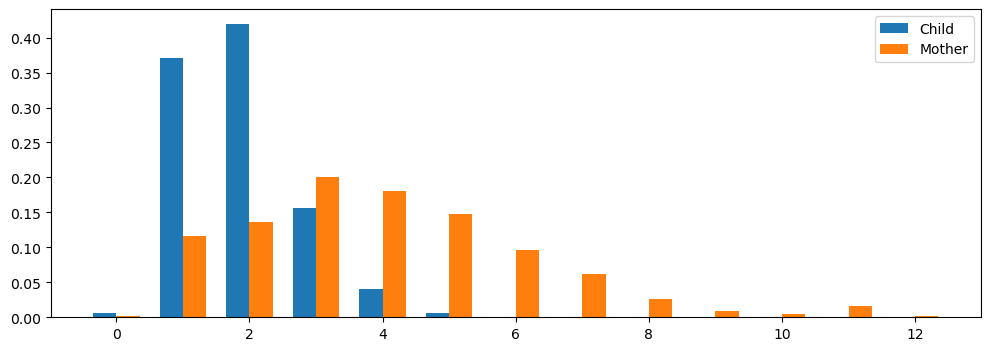

In [26]:
# plot probs for both spkrs.  

plt.figure(figsize=(12,4))
width = 0.35  # the width of the bars
x = np.array(list(probs['CHI'].keys()))
plt.bar(x-width/2,probs['CHI'].values(),width,label='Child')
plt.bar(x+width/2,probs['MOT'].values(),width,label='Mother')
plt.legend()
plt.show()

---
**2 points for the following cell**:

In [27]:
# compute and print out entropy for each speaker, based on the probabilities you just obtained.
# note that we are assuming log is log base 2.
for who in ['MOT','CHI']:
    H = 0.0  # REPLACE WITH YOUR CODE.
    for key in probs[who].keys():
        if probs[who][key] != 0:
            H = H + probs[who][key] * math.log2(1 / (probs[who][key]))
    print("Entropy of word use for", who, "is", H)

Entropy of word use for MOT is 3.0137637603421656
Entropy of word use for CHI is 1.7578605625090298


### What happens with age?

- The file we used here was Brown/Adam/020304.xml, which contains a transcript collected when the child Adam was 2 years, 3 months, and 4 days of age - this is the youngest age for which we have data for Adam.  An obvious question is how the pattern we found changes with age.
- To answer this, run the whole thing again but using a different transcript of the same child: Brown/Adam/050212.xml contains data from when Adam was 5 years, 2 months, and 12 days of age.

---
**8 points for observations and conclusions**:
- 2 points for observations about Adam at the younger of the two ages
- 2 points for observations about Adam at the older of the two ages
- 2 points for comparison of results obtained at the two ages
- 2 points for conclusions drawn from the observations

At first, when Adam was 2 years old, the mother's word use entropy was at 3.01, while Adam's entropy was at 1.7. This suggests that while the mother was forming more complex, less predictable sentences, her child was forming much simpler ones. 
When Adam was five, his word use entropy rose to 3.2, more complex than his mother's when he was two years old. His mother's entropy also rose to 3.4. Both agents saw a rise in their entropy. This suggests that as Adam got older, not only did his sentence complexity increase, but his mother's sentence complexity increased in tandem, likely because the two were having more complex conversations. Adam had a larger vocabulary, which meant the two had access to more words, and therefore that more unique words could be used in each utterance. In addition, utterances were likely becoming longer and more complex, which would naturally lead to more unique words per utterance. 

# Observations and conclusions.

- Write your general observations about the results here.  A few short sentences would be fine.  Please include a **comparison** of patterns found at the two ages probed.  Please also say what we may conclude from the observations.

---
**4 points for the following cell, on optional extensions - but those points will be awarded only if you are not already at full credit.**

# Some possibilities for extension (optional)

- Do the same thing for the other children in the Brown corpus: Eve and Sarah.
- Do the same thing for other participants in each corpus - e.g. 'URS' = Ursula Bellugi, the investigator.
- Track change more closely over time: consider not just the first and last transcript for each child, but all transcripts, to get a more fine-grained picture of change over time.
- Consider languages other than English.
- Etc.

# Grading

**Points**: 26/26

Code runs smoothly! Good job:)